# Phase 3 — Synthetic anomaly injection

Anomaly detection here is **unsupervised**: the models train on all the data
without labels. The problem is that without labels we cannot measure how well
they detect. The solution: take clean series, **inject anomalies whose type and
position we know**, score, and compare detections to injected positions. This
yields a real precision/recall in an otherwise label-free setting.

> **Key principle:** the labels exist only to *measure*. They never enter
> training. The model stays purely unsupervised; injection is a measurement
> instrument bolted on top.

Reusable code lives in `src/evaluation/injection.py`; this notebook imports it,
runs it, and shows the validations.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from pyspark.sql import Window, functions as F
import matplotlib.pyplot as plt

from src.config import DATA_DIR
from src.data.aggregate import get_spark
from src.evaluation.injection import (
    build_injection_pool, inject_spike, inject_drop,
    inject_contextual, inject_level_shift,
    recompute_features_simple, recompute_features_level_shift,
    build_eval_set, SEVERITY_GRID,
)

spark = get_spark()
features = spark.read.parquet(str(DATA_DIR / "features.parquet"))
print("feature rows:", features.count())

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/13 16:27:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/13 16:27:47 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


feature rows: 3422718


The injection pool: one target week per series, drawn from the fully-valid zone
(YoY present => at least 52 weeks of history). Same pool reused across all
anomaly types and severities.

In [2]:
pool = build_injection_pool(features, n_series=3000)
print("pool:", pool.count(), "series")

pool: 3000 series


## Anomaly types

Four types, each tied to a feature it is meant to exercise:

- **spike / drop** — point shock of ±k·σ, surfaces in the rolling z-score
- **contextual** — value plausible in absolute terms but wrong for the season;
  hidden from the z-score, visible only in the YoY ratio
- **level_shift** — a *sustained* regime change; the case a rolling detector
  gradually absorbs, motivating the sequence-based autoencoder

Magnitude is always relative to local variance (k·σ), never absolute.

### Spike

Replace the target week with `roll_mean + k·roll_std`. By construction the
recomputed z-score should land near k — a self-consistency check between the
injection and the feature recomputation.

In [3]:
spk = recompute_features_simple(inject_spike(pool, k=3.0))

s = spk.select(
    F.mean("sales_zscore").alias("mean_z"),
    F.min("sales_zscore").alias("min_z"),
    F.max("sales_zscore").alias("max_z"),
).first()
print(f"spike recomputed z-score  mean={s['mean_z']:.2f}  "
      f"min={s['min_z']:.2f}  max={s['max_z']:.2f}   (expect ~3)")

spike recomputed z-score  mean=3.00  min=2.25  max=3.55   (expect ~3)


### Drop

Symmetric to the spike (`roll_mean - k·roll_std`), but **volume-restricted**: on
low-volume series `mean - k·σ` collapses below zero, degrading the drop into a
binary zeroing. We inject drops only where `mean - k·σ > 0`, so the drop stays a
graded anomaly. Consequence: fewer series at higher k, and drop recall is
measured on high-volume, low-relative-variance series — a documented scope limit.

In [4]:
for k in [2.0, 3.0, 4.0]:
    n = inject_drop(pool, k=k).count()
    print(f"valid drops at k={k}: {n}/3000")

valid drops at k=2.0: 1546/3000
valid drops at k=3.0: 596/3000
valid drops at k=4.0: 232/3000


### Contextual

Replace the target week with the series' own value from an opposite-season week
(~26 weeks away). The value is plausible in absolute terms but wrong for the
season. Expectation: **modest |z-score|** (hidden from the local detector) but a
**large |yoy_ratio - 1|** (revealed by the seasonal feature). This demonstrates
that the anomaly types exercise *distinct* features.

In [5]:
ctx = recompute_features_simple(inject_contextual(pool, features))

c = ctx.select(
    F.mean(F.abs("sales_zscore")).alias("mean_abs_z"),
    F.mean(F.abs(F.col("yoy_ratio") - 1)).alias("mean_yoy_dev"),
).first()
print(f"contextual  mean|z|={c['mean_abs_z']:.2f}  "
      f"mean|yoy-1|={c['mean_yoy_dev']:.2f}")
print("=> hidden from z-score, revealed by YoY")

contextual  mean|z|=1.47  mean|yoy-1|=1.09
=> hidden from z-score, revealed by YoY


### Level shift

A sustained level break: from the target week onward (8 weeks), sales jump by
k·σ. Unlike a spike this anomaly *affects multiple consecutive weeks*. The feature
recomputation replays the rolling window on the modified series, so the shift is
progressively **factored in** into the rolling mean — exactly what makes a rolling
detector blind to regime change, and the justification for the future AE.

In [6]:
lvl = recompute_features_level_shift(
    inject_level_shift(pool, features, k=3.0, horizon=8), features)

# Mean recomputed z-score by week-since-shift: should decay monotonically.
prog = (
    lvl
    .withColumn("wk_since",
        F.row_number().over(Window.partitionBy("id").orderBy("wm_yr_wk")) - 1)
    .groupBy("wk_since")
    .agg(F.mean("sales_zscore").alias("mean_z"), F.count("*").alias("n"))
    .orderBy("wk_since")
    .toPandas()
)
prog

,wk_since,mean_z,n
0,0,3.010451,3000
1,1,2.167325,2966
2,2,1.757732,2929
3,3,1.452276,2904
4,4,1.225034,2876
5,5,1.071788,2853
6,6,0.885829,2831
7,7,0.785385,2814


#### The absorption curve

This is the conceptual figure of the project: the rolling z-score of a sustained
shift decays week after week as the window swallows the new level. A rolling
detector flags the onset and goes blind to the persistence.

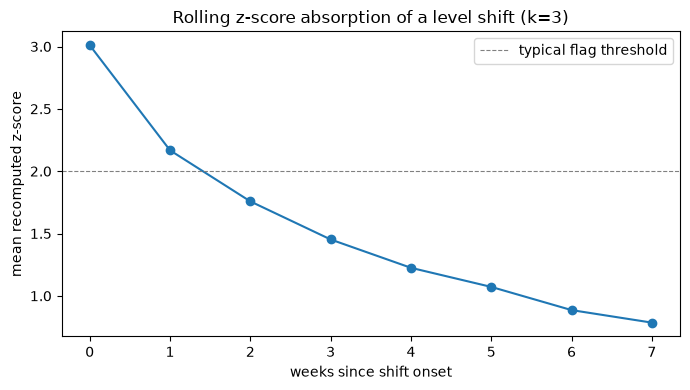

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(prog["wk_since"], prog["mean_z"], marker="o")
ax.axhline(2.0, color="gray", ls="--", lw=0.8, label="typical flag threshold")
ax.set_xlabel("weeks since shift onset")
ax.set_ylabel("mean recomputed z-score")
ax.set_title("Rolling z-score absorption of a level shift (k=3)")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation set

Assemble one labelled set: injected anomalies (`label=1`) at several severities
+ untouched normal weeks (`label=0`). The same series pool is used across all k,
so the recall-vs-severity curve varies only severity, not the underlying series.
Negatives are the normal weeks of the injected series, excluding the injected
cells — needed to measure precision, not just recall.

In [8]:
eval_set = build_eval_set(features, pool)

eval_set.groupBy("label").count().show()
eval_set.filter(F.col("label") == 1) \
    .groupBy("anomaly_type", "severity_k").count() \
    .orderBy("anomaly_type", "severity_k").show(30)

+-----+------+
|label| count|
+-----+------+
|    1|137589|
|    0|456884|
+-----+------+



+------------+----------+-----+
|anomaly_type|severity_k|count|
+------------+----------+-----+
|  contextual|      NULL| 3000|
|        drop|       2.0| 1546|
|        drop|       2.5|  982|
|        drop|       3.0|  596|
|        drop|       3.5|  368|
|        drop|       4.0|  232|
| level_shift|       2.0|23173|
| level_shift|       2.5|23173|
| level_shift|       3.0|23173|
| level_shift|       3.5|23173|
| level_shift|       4.0|23173|
|       spike|       2.0| 3000|
|       spike|       2.5| 3000|
|       spike|       3.0| 3000|
|       spike|       3.5| 3000|
|       spike|       4.0| 3000|
+------------+----------+-----+



## Reading the eval set: metrics per type, never aggregated

Level shifts are ~84% of injected positives (8 labelled weeks each vs 1 for the
other types), so a single global PR-AUC would just reflect level-shift
performance and hide, say, missed contextual anomalies. Therefore:

- report **PR-AUC and recall separately per anomaly type**
- **recall-vs-severity** is one curve per k-dependent type (spike, drop,
  level_shift); contextual is a single point (severity is intrinsic)
- prefer **PR-AUC over ROC-AUC**: the per-type positive:negative ratio is
  extreme (e.g. spike ~1:150), where ROC-AUC is misleadingly optimistic

These are the metrics computed in Phase 4 against this eval set.